In [11]:
from PIL import Image
from torchvision.transforms.functional import to_tensor
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Set the path to your image (e.g., PNG or JPEG)
image_path = "/home/demo-user/Downloads/LoTSS files/GAN DATA/test99_region_11_z0.10.jpg"  # Change this as needed
image_name = os.path.basename(image_path)

# Load and convert image to grayscale (if not already)
img = Image.open(image_path).convert("L")  # Convert to grayscale
image_data = np.array(img)

# Apply z-scale stretch---------------------------------------------------------------------------
RuntimeError                              Traceback (most recent call last)
Cell In[31], line 59
     56 ras, decs = get_apertif_hi_centers(limit=3000)
     58 # 2) LoTSS DR2 MOC from CDS
---> 59 dr2_moc = fetch_lotss_dr2_moc(order="12")
     61 # 3) keep only centers inside DR2
     62 inside = dr2_moc.contains_lonlat(ras * u.deg, decs * u.deg)

Cell In[31], line 37, in fetch_lotss_dr2_moc(order)
     35         except Exception:
     36             pass
---> 37 raise RuntimeError("Could not fetch LoTSS DR2 MOC from CDS (try again or check network).")

RuntimeError: Could not fetch LoTSS DR2 MOC from CDS (try again or check network).
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image_data)
scaled_data = (image_data - vmin) / (vmax - vmin)
scaled_data = scaled_data.clip(0, 1)

# Preprocess
image_tensor = to_tensor(scaled_data.astype('float32'))
if image_tensor.ndim == 2:
    image_tensor = image_tensor.unsqueeze(0)
image_tensor = image_tensor.unsqueeze(0)

# Run inference
with torch.no_grad():
    outputs = model(image_tensor)

#  Extract and threshold detections
boxes = outputs[0]['boxes']
scores = outputs[0]['scores']
threshold = 0.5
detected = [(box, score) for box, score in zip(boxes, scores) if score > threshold]

#  Plot full image with detections
fig, ax = plt.subplots()
ax.imshow(image_data, cmap='gray', origin='lower')
for i, (box, score) in enumerate(detected):
    x1, y1, x2, y2 = map(int, box.tolist())
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=1)
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f'{score:.2f}', color='yellow', fontsize=8)

    # Cropped view
    crop = image_data[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    plt.figure()
    plt.imshow(crop, cmap='gray', origin='lower')
    plt.title(f"{image_name} | Galaxy {i+1} @ ({(x1+x2)//2}, {(y1+y2)//2}) | Conf: {score:.2f}")
    plt.axis('off')

plt.title(f"Detections in {image_name}")
plt.show()


SyntaxError: invalid syntax (1312317308.py, line 17)

In [5]:
import os
import random
from PIL import Image
from torchvision.transforms.functional import to_tensor
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

#  Folder containing images (non-FITS)
image_folder = "/home/demo-user/Downloads/LoTSS files/wildones"  # Change as needed
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

# Select a random image
selected_image = random.choice(image_files)
image_path = os.path.join(image_folder, selected_image)

# Load and prepare the image
img = Image.open(image_path).convert("L")  # Convert to grayscale
image_data = np.array(img)

# Z-scale normalization
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image_data)
scaled_data = (image_data - vmin) / (vmax - vmin)
scaled_data = scaled_data.clip(0, 1)

# Preprocess for model
image_tensor = to_tensor(scaled_data.astype('float32'))
if image_tensor.ndim == 2:
    image_tensor = image_tensor.unsqueeze(0)
image_tensor = image_tensor.unsqueeze(0)

# Inference
with torch.no_grad():
    outputs = model(image_tensor)

# Parse detections
boxes = outputs[0]['boxes']
scores = outputs[0]['scores']
threshold = 0.5
detected = [(box, score) for box, score in zip(boxes, scores) if score > threshold]

# Show detections
fig, ax = plt.subplots()
ax.imshow(image_data, cmap='gray', origin='lower')
for i, (box, score) in enumerate(detected):
    x1, y1, x2, y2 = map(int, box.tolist())
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=1)
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f'{score:.2f}', color='yellow', fontsize=8)

    # Show crop
    crop = image_data[y1:y2, x1:x2]
    if crop.size == 0:
        continue
    plt.figure()
    plt.imshow(crop, cmap='gray', origin='lower')
    plt.title(f"{selected_image} | Galaxy {i+1} @ ({(x1+x2)//2}, {(y1+y2)//2}) | Conf: {score:.2f}")
    plt.axis('off')

plt.title(f"Detections in {selected_image}")
plt.show()


NameError: name 'torch' is not defined

Using device: cuda
Processing image of size: 19845x19845


Processing Tiles: 100%|█████████████████████| 5776/5776 [10:33<00:00,  9.11it/s]


Detection complete in 633.70 seconds
Raw detections before NMS: 469
Detections after NMS: 340


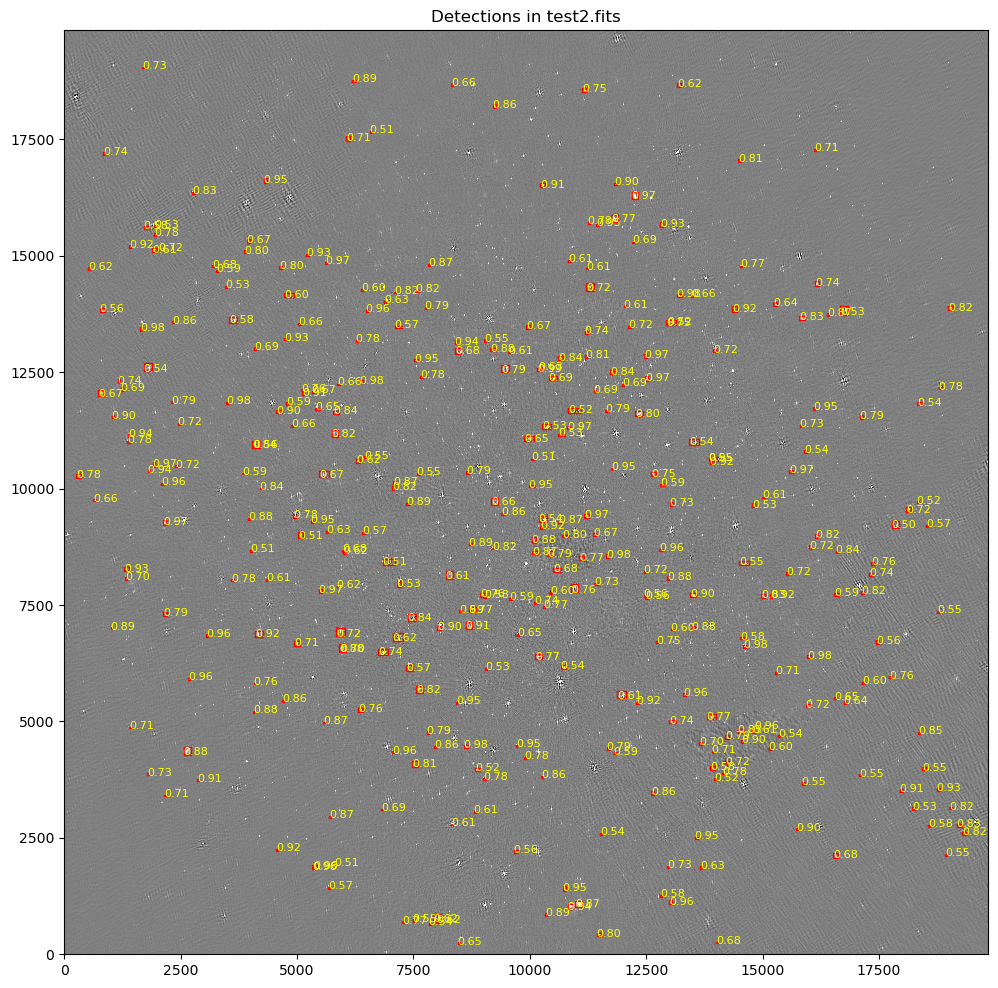

In [19]:
import os
import numpy as np
import torch
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from torchvision.transforms.functional import to_tensor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import nms
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tqdm import tqdm
import time

# === CONFIGURATION ===
fits_path = "/home/demo-user/Downloads/LoTSS files/Test 1/test2.fits"
model_path = "/home/demo-user/Downloads/faster_rcnn_galaxy.pth"
tile_size = 512
stride = 256
conf_threshold = 0.5
nms_threshold = 0.3
max_detections_per_tile = 20

# === LOAD MODEL ===
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = fasterrcnn_resnet50_fpn(weights=None)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# === LOAD IMAGE — handle 4D FITS ===
hdul = fits.open(fits_path)
image_data = hdul[0].data
hdul.close()

while image_data.ndim > 2:
    image_data = image_data[0]

height, width = image_data.shape
print(f"Processing image of size: {width}x{height}")

# === SLIDING WINDOW INFERENCE ===
all_boxes = []
all_scores = []
interval = ZScaleInterval()

x_steps = range(0, width - tile_size + 1, stride)
y_steps = range(0, height - tile_size + 1, stride)

start_time = time.time()
tile_iter = tqdm([(x, y) for y in y_steps for x in x_steps], desc="Processing Tiles")

for x, y in tile_iter:
    tile = image_data[y:y + tile_size, x:x + tile_size]
    if np.all(tile == 0) or np.isnan(tile).any():
        continue

    vmin, vmax = interval.get_limits(tile)
    tile_norm = (tile - vmin) / (vmax - vmin)
    tile_norm = tile_norm.clip(0, 1).astype(np.float32)

    tensor = [to_tensor(tile_norm).to(device)]

    with torch.no_grad():
        outputs = model(tensor)[0]

    for box, score in zip(outputs['boxes'][:max_detections_per_tile],
                          outputs['scores'][:max_detections_per_tile]):
        if score < conf_threshold:
            continue
        x1, y1, x2, y2 = box.tolist()
        all_boxes.append([x1 + x, y1 + y, x2 + x, y2 + y])
        all_scores.append(score.item())

elapsed = time.time() - start_time
print(f"Detection complete in {elapsed:.2f} seconds")
print(f"Raw detections before NMS: {len(all_boxes)}")

# === NMS + VISUALISATION ===
if all_boxes:
    boxes_tensor = torch.tensor(all_boxes)
    scores_tensor = torch.tensor(all_scores)
    keep_indices = nms(boxes_tensor, scores_tensor, nms_threshold)

    final_boxes = boxes_tensor[keep_indices].int()
    final_scores = scores_tensor[keep_indices]

    print(f"Detections after NMS: {len(final_boxes)}")

    fig, ax = plt.subplots(figsize=(12, 12))
    vmin, vmax = interval.get_limits(image_data)
    ax.imshow(image_data, cmap="gray", vmin=vmin, vmax=vmax, origin='lower')
    for box, score in zip(final_boxes, final_scores):
        x1, y1, x2, y2 = box.tolist()
        rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                         linewidth=1, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{score:.2f}", color="yellow", fontsize=8)
    plt.title(f"Detections in {os.path.basename(fits_path)}")
    plt.show()
else:
    print("No detections found.")

In [9]:
from astropy.wcs import WCS
from astropy.io import fits

# Load WCS from FITS header
hdul = fits.open(fits_path)
wcs = WCS(hdul[0].header)
hdul.close()

# Output path for .reg file
reg_path = fits_path.replace(".fits", "_detections_wcs.reg")

with open(reg_path, "w") as f:
    f.write("# Region file format: DS9 version 4.1\n")
    f.write("global color=red dashlist=8 3 width=1 font=\"helvetica 10 normal\" select=1 highlite=1 "
            "dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1\n")
    f.write("fk5\n")  

    for box, score in zip(final_boxes, final_scores):
        x1, y1, x2, y2 = box.tolist()
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        w = x2 - x1
        h = y2 - y1

        # Convert pixel to WCS (RA, Dec)
        ra, dec = wcs.wcs_pix2world([[cx, cy]], 0)[0]

        # Convert pixel width/height to angular sizes (approximate)
        ra2, dec2 = wcs.wcs_pix2world([[cx + w / 2, cy + h / 2]], 0)[0]
        dra = abs(ra2 - ra) * 3600  # arcsec
        ddec = abs(dec2 - dec) * 3600  # arcsec

        f.write(f"box({ra:.6f},{dec:.6f},{dra:.2f}\",{ddec:.2f}\",0) # text={{Conf: {score:.2f}}}\n")

print(f" DS9 WCS region file saved to:\n{reg_path}")


NameError: name 'final_boxes' is not defined